# Diamond Price Prediction: Final Data Science Project
**Problem:** Price a diamond from its physical grading attributes (the 4 Cs plus dimensions), and quantify the uncertainty of each estimate.

**Why it matters:** A jeweller or marketplace needs fast, consistent price estimates and a sense of how far off they might be.

**Pipeline:** Data quality checks → EDA → Feature engineering → Model comparison → Tuning → Test evaluation → Error analysis → Prediction intervals → Explainability → Conclusions

**Author:** Murali · Final-year B.Tech AI & Data Science

In [1]:
import warnings; warnings.filterwarnings('ignore')
import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_validate, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance
sns.set_theme(style='whitegrid'); RS = 42

## 1. Data and Quality Checks
Classic diamonds dataset (53,940 rows): carat, cut, colour, clarity, depth, table, x/y/z dimensions and price in USD.

In [2]:
URL = 'https://raw.githubusercontent.com/mwaskom/seaborn-data/master/diamonds.csv'
df = pd.read_csv(URL)
print(df.shape); print('Missing:', df.isna().sum().sum(), '| Duplicates:', df.duplicated().sum())
print('Rows with a zero dimension:', ((df[['x','y','z']]==0).any(axis=1)).sum())
print('Extreme dimensions (y>20 or z>10):', ((df.y>20)|(df.z>10)).sum())
df.describe().T

(53940, 10)
Missing: 0 | Duplicates: 146
Rows with a zero dimension: 20
Extreme dimensions (y>20 or z>10): 3


,count,mean,std,min,25%,50%,75%,max
carat,53940.0,0.797940,0.474011,0.2,0.40,0.70,1.04,5.01
depth,53940.0,61.749405,1.432621,43.0,61.00,61.80,62.50,79.00
table,53940.0,57.457184,2.234491,43.0,56.00,57.00,59.00,95.00
price,53940.0,3932.799722,3989.439738,326.0,950.00,2401.00,5324.25,18823.00
x,53940.0,5.731157,1.121761,0.0,4.71,5.70,6.54,10.74
y,53940.0,5.734526,1.142135,0.0,4.72,5.71,6.54,58.90
z,53940.0,3.538734,0.705699,0.0,2.91,3.53,4.04,31.80


In [3]:
n0 = len(df)
df = df.drop_duplicates()
df = df[(df[['x','y','z']]>0).all(axis=1) & (df.y<20) & (df.z<10)]
print(f'Removed {n0-len(df)} rows ({(n0-len(df))/n0:.2%}); remaining {len(df)}')

Removed 168 rows (0.31%); remaining 53772


## 2. Exploratory Data Analysis

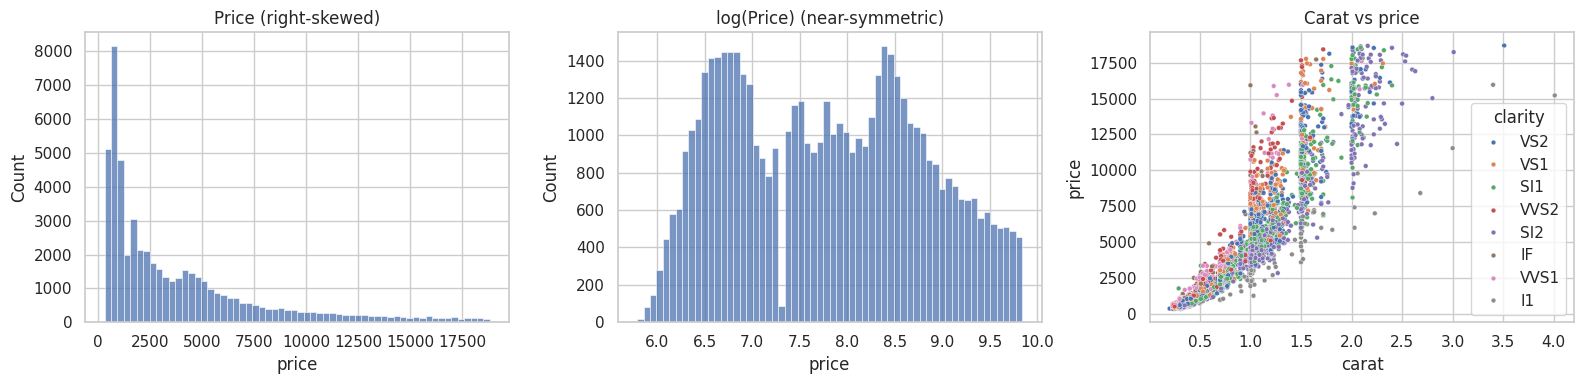

In [4]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
sns.histplot(df.price, bins=60, ax=ax[0]); ax[0].set_title('Price (right-skewed)')
sns.histplot(np.log(df.price), bins=60, ax=ax[1]); ax[1].set_title('log(Price) (near-symmetric)')
sns.scatterplot(data=df.sample(5000, random_state=RS), x='carat', y='price', hue='clarity', s=12, ax=ax[2]); ax[2].set_title('Carat vs price')
plt.tight_layout(); plt.show()

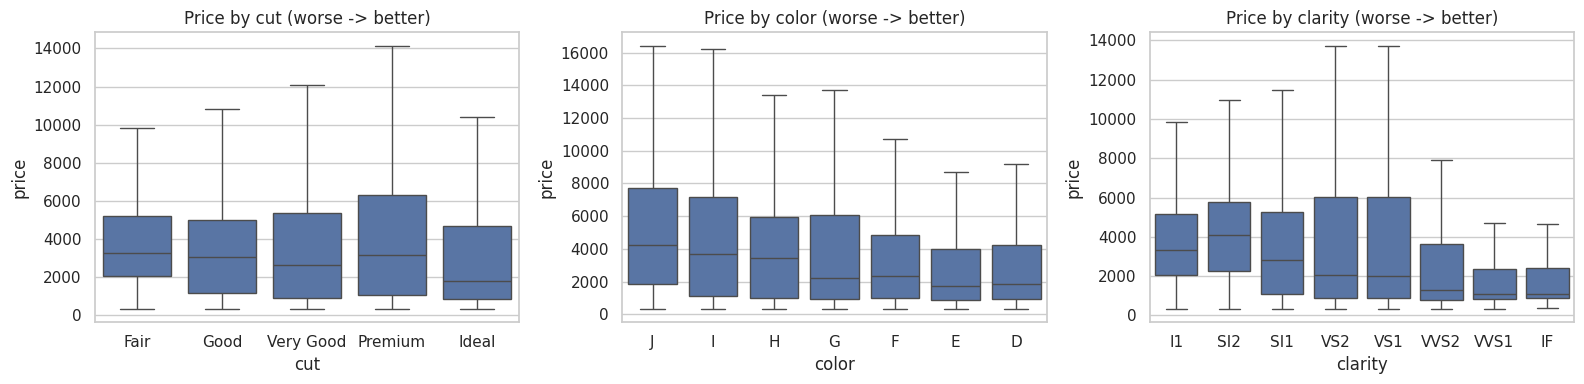

carat    0.922
x        0.887
y        0.889
z        0.882
depth   -0.011
table    0.127
price    1.000
Name: price, dtype: float64

Mean carat by cut:
cut
Fair         1.04
Good         0.85
Very Good    0.81
Premium      0.89
Ideal        0.70
Name: carat, dtype: float64


In [5]:
fig, ax = plt.subplots(1,3, figsize=(16,4))
for a,col,order in zip(ax,['cut','color','clarity'],
    [['Fair','Good','Very Good','Premium','Ideal'], list('JIHGFED'), ['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']]):
    sns.boxplot(data=df, x=col, y='price', order=order, ax=a, showfliers=False); a.set_title(f'Price by {col} (worse -> better)')
plt.tight_layout(); plt.show()
print(df[['carat','x','y','z','depth','table','price']].corr()['price'].round(3))
print(); print('Mean carat by cut:'); print(df.groupby('cut').carat.mean().reindex(['Fair','Good','Very Good','Premium','Ideal']).round(2))

**Observations**
1. Price is heavily right-skewed, so modelling `log(price)` stabilises variance and makes errors proportional.
2. Carat dominates price, and size columns (`x`,`y`,`z`) are almost perfectly collinear with carat.
3. Counter-intuitively, the lowest cut/colour grades are not the cheapest in the boxplots, because lower grades tend to be larger stones. This is a confounding effect that a model must control for with carat.

## 3. Feature Engineering

In [6]:
df['volume'] = df.x*df.y*df.z
df['depth_pct_calc'] = 2*df.z/(df.x+df.y)*100
df['log_carat'] = np.log(df.carat)
cut_o=['Fair','Good','Very Good','Premium','Ideal']; col_o=list('JIHGFED'); cla_o=['I1','SI2','SI1','VS2','VS1','VVS2','VVS1','IF']
X = df.drop(columns='price'); y = np.log(df.price)
ordcols=['cut','color','clarity']; numcols=[c for c in X.columns if c not in ordcols]
pre = ColumnTransformer([('ord', OrdinalEncoder(categories=[cut_o,col_o,cla_o]), ordcols),
                         ('num', StandardScaler(), numcols)])
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=.2, random_state=RS)
cv = KFold(5, shuffle=True, random_state=RS)
print('Features:', list(X.columns))

Features: ['carat', 'cut', 'color', 'clarity', 'depth', 'table', 'x', 'y', 'z', 'volume', 'depth_pct_calc', 'log_carat']


## 4. Model Comparison (5-fold CV, training set)
Metrics: RMSE on log scale (approx. relative error) and MAE in dollars.

In [7]:
from sklearn.metrics import make_scorer
def usd_mae(y_true, y_pred): return mean_absolute_error(np.exp(y_true), np.exp(y_pred))
scoring = {'rmse_log': 'neg_root_mean_squared_error', 'mae_usd': make_scorer(usd_mae), 'r2': 'r2'}
models = {
 'Ridge (baseline)': Ridge(alpha=1.0),
 'Random Forest': RandomForestRegressor(n_estimators=100, min_samples_leaf=2, random_state=RS, n_jobs=-1),
 'Hist Gradient Boosting': HistGradientBoostingRegressor(random_state=RS),
}
rows=[]
for n,m in models.items():
    r = cross_validate(Pipeline([('pre',pre),('m',m)]), X_tr, y_tr, cv=cv, scoring=scoring, n_jobs=1)
    rows.append((n, -r['test_rmse_log'].mean(), r['test_mae_usd'].mean(), r['test_r2'].mean()))
res = pd.DataFrame(rows, columns=['model','cv_rmse_log','cv_mae_usd','cv_r2']).sort_values('cv_rmse_log')
res.round(4)

,model,cv_rmse_log,cv_mae_usd,cv_r2
1,Random Forest,0.0903,271.2457,0.9921
2,Hist Gradient Boosting,0.0906,277.5372,0.9920
0,Ridge (baseline),0.1413,443.4749,0.9806


## 5. Hyperparameter Tuning

In [8]:
gs = GridSearchCV(Pipeline([('pre',pre),('m',HistGradientBoostingRegressor(random_state=RS))]),
    {'m__learning_rate':[.05,.1], 'm__max_depth':[None,10], 'm__max_iter':[600]},
    cv=cv, scoring='neg_root_mean_squared_error', n_jobs=-1).fit(X_tr, y_tr)
print('Best params:', gs.best_params_); print('CV RMSE (log):', round(-gs.best_score_,4))
best = gs.best_estimator_

Best params: {'m__learning_rate': 0.05, 'm__max_depth': None, 'm__max_iter': 600}
CV RMSE (log): 0.0868


## 6. Final Evaluation on Held-Out Test Set

R2 (log scale): 0.9918
MAE: $268 | RMSE: $526 | MAPE: 6.47%


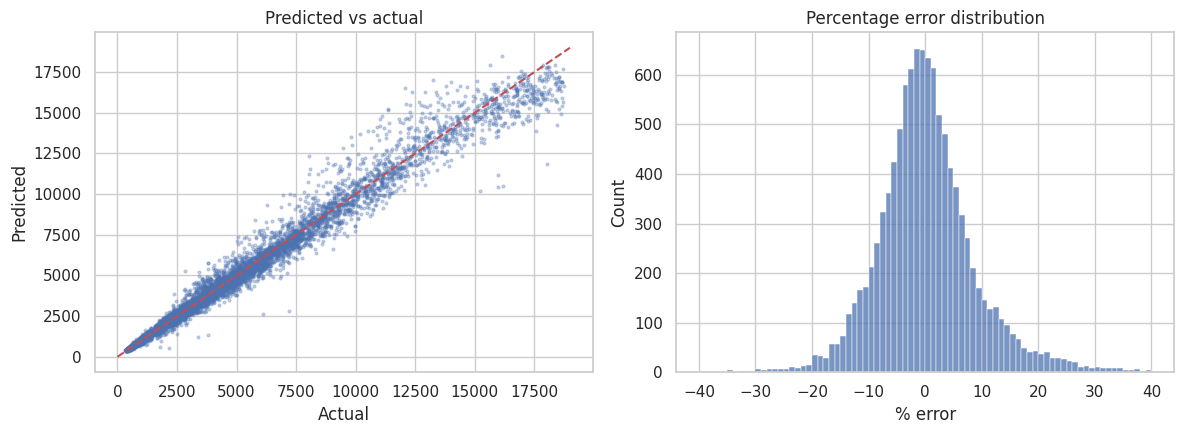

In [9]:
pred = np.exp(best.predict(X_te)); true = np.exp(y_te)
mae = mean_absolute_error(true,pred); rmse = mean_squared_error(true,pred)**.5
mape = np.mean(np.abs(true-pred)/true)*100
print(f'R2 (log scale): {r2_score(y_te, np.log(pred)):.4f}')
print(f'MAE: ${mae:,.0f} | RMSE: ${rmse:,.0f} | MAPE: {mape:.2f}%')
fig, ax = plt.subplots(1,2, figsize=(12,4.5))
ax[0].scatter(true, pred, s=4, alpha=.3); lim=[0,19000]; ax[0].plot(lim,lim,'r--'); ax[0].set_xlabel('Actual'); ax[0].set_ylabel('Predicted'); ax[0].set_title('Predicted vs actual')
sns.histplot((pred-true)/true*100, bins=80, ax=ax[1], binrange=(-40,40)); ax[1].set_title('Percentage error distribution'); ax[1].set_xlabel('% error')
plt.tight_layout(); plt.show()

## 7. Error Analysis
Where does the model struggle?

In [10]:
err = pd.DataFrame({'carat':X_te.carat.values,'clarity':X_te.clarity.values,'true':true.values,'pct_err':np.abs(pred-true.values)/true.values*100})
err['carat_band'] = pd.cut(err.carat,[0,.5,1,1.5,2,6])
print(err.groupby('carat_band').pct_err.agg(['mean','median','count']).round(2))
print(); print(err.groupby('clarity').pct_err.mean().round(2).sort_values())

            mean  median  count
carat_band                     
(0.0, 0.5]  5.78    4.25   3770
(0.5, 1.0]  6.50    4.80   3501
(1.0, 1.5]  6.80    4.90   2422
(1.5, 2.0]  7.66    5.23    697
(2.0, 6.0]  8.81    6.70    365

clarity
IF       5.73
VS2      5.73
VS1      5.99
VVS1     6.12
VVS2     6.16
SI1      6.62
SI2      7.62
I1      12.82
Name: pct_err, dtype: float64


## 8. Prediction Intervals
A point estimate is not enough for pricing. We train quantile models (5th and 95th percentile) with the tuned settings to give a ~90% range, then check real coverage on the test set.

In [11]:
params = {k.replace('m__',''):v for k,v in gs.best_params_.items()}
qmodels = {q: Pipeline([('pre',pre),('m',HistGradientBoostingRegressor(loss='quantile', quantile=q, random_state=RS, **params))]).fit(X_tr,y_tr) for q in (.05,.95)}
lo = np.exp(qmodels[.05].predict(X_te)); hi = np.exp(qmodels[.95].predict(X_te))
cov = np.mean((true.values>=lo)&(true.values<=hi))
print(f'Empirical coverage of the nominal 90% interval: {cov:.1%}  |  median interval width: ${np.median(hi-lo):,.0f}')
demo = X_te.iloc[:5].copy(); demo['actual']=true.values[:5].round(0); demo['pred']=pred[:5].round(0); demo['low_5%']=lo[:5].round(0); demo['high_95%']=hi[:5].round(0)
demo[['carat','cut','color','clarity','actual','pred','low_5%','high_95%']]

Empirical coverage of the nominal 90% interval: 85.1%  |  median interval width: $612


,carat,cut,color,clarity,actual,pred,low_5%,high_95%
6408,0.76,Ideal,E,VS2,4039.0,3378.0,3011.0,3852.0
2676,0.70,Very Good,D,VS1,3239.0,3355.0,2983.0,4052.0
15150,1.11,Ideal,I,SI1,6090.0,4845.0,4251.0,5559.0
18191,1.09,Very Good,G,VS1,7378.0,6876.0,6528.0,7487.0
41308,0.57,Premium,I,VS1,1212.0,1456.0,1332.0,1715.0


## 9. Explainability

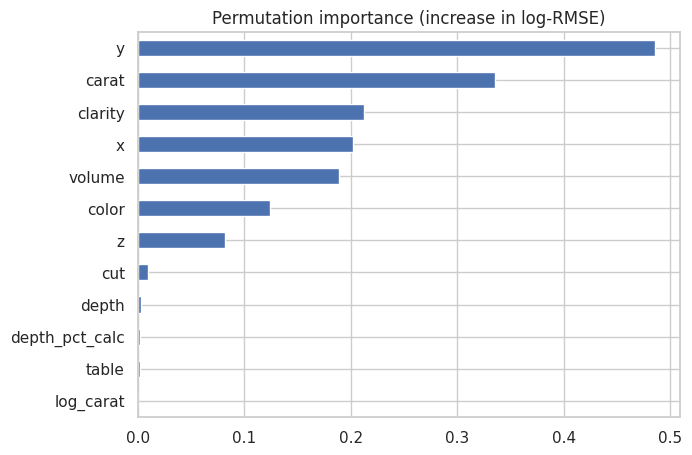

y                 0.4856
carat             0.3359
clarity           0.2125
x                 0.2026
volume            0.1894
color             0.1242
z                 0.0822
cut               0.0098
depth             0.0024
depth_pct_calc    0.0018
table             0.0015
log_carat         0.0000
dtype: float64

In [12]:
sub = X_te.sample(4000, random_state=RS); ysub = y_te.loc[sub.index]
pi = permutation_importance(best, sub, ysub, n_repeats=8, random_state=RS, scoring='neg_root_mean_squared_error', n_jobs=-1)
imp = pd.Series(pi.importances_mean, index=X.columns).sort_values()
imp.plot.barh(figsize=(7,5), color='#4C72B0'); plt.title('Permutation importance (increase in log-RMSE)'); plt.show()
imp.sort_values(ascending=False).round(4)

## 10. Conclusions
- Log-transforming the target and tuning gradient boosting gave a model with low relative error across the price range (see MAE/MAPE above), clearly beating the linear baseline.
- Size features (carat, x/y/z, volume) dominate importance, then clarity and colour. Cut and depth/table add very little once size is known. Because the size features are highly collinear, permutation importance splits credit between them, so read it as "size matters most", not as a ranking of individual columns.
- Error analysis shows relative error grows for larger stones and is worst for the lowest clarity grade (I1), where there is less data and more price variance.
- The quantile intervals are useful but slightly under-cover (see coverage above vs the nominal 90%). Conformal calibration would be the next step to fix this.

**Limitations:** the data is a historical snapshot with no market-time component, only grading attributes are used (no certification lab, fluorescence, or polish), and the model should not be used for real financial appraisal.

**Next steps:** add SHAP explanations, a Streamlit pricing app with the intervals, and monitoring for price drift.